# 手撕一个Transformer架构

先查看Transformer整体的结构图：
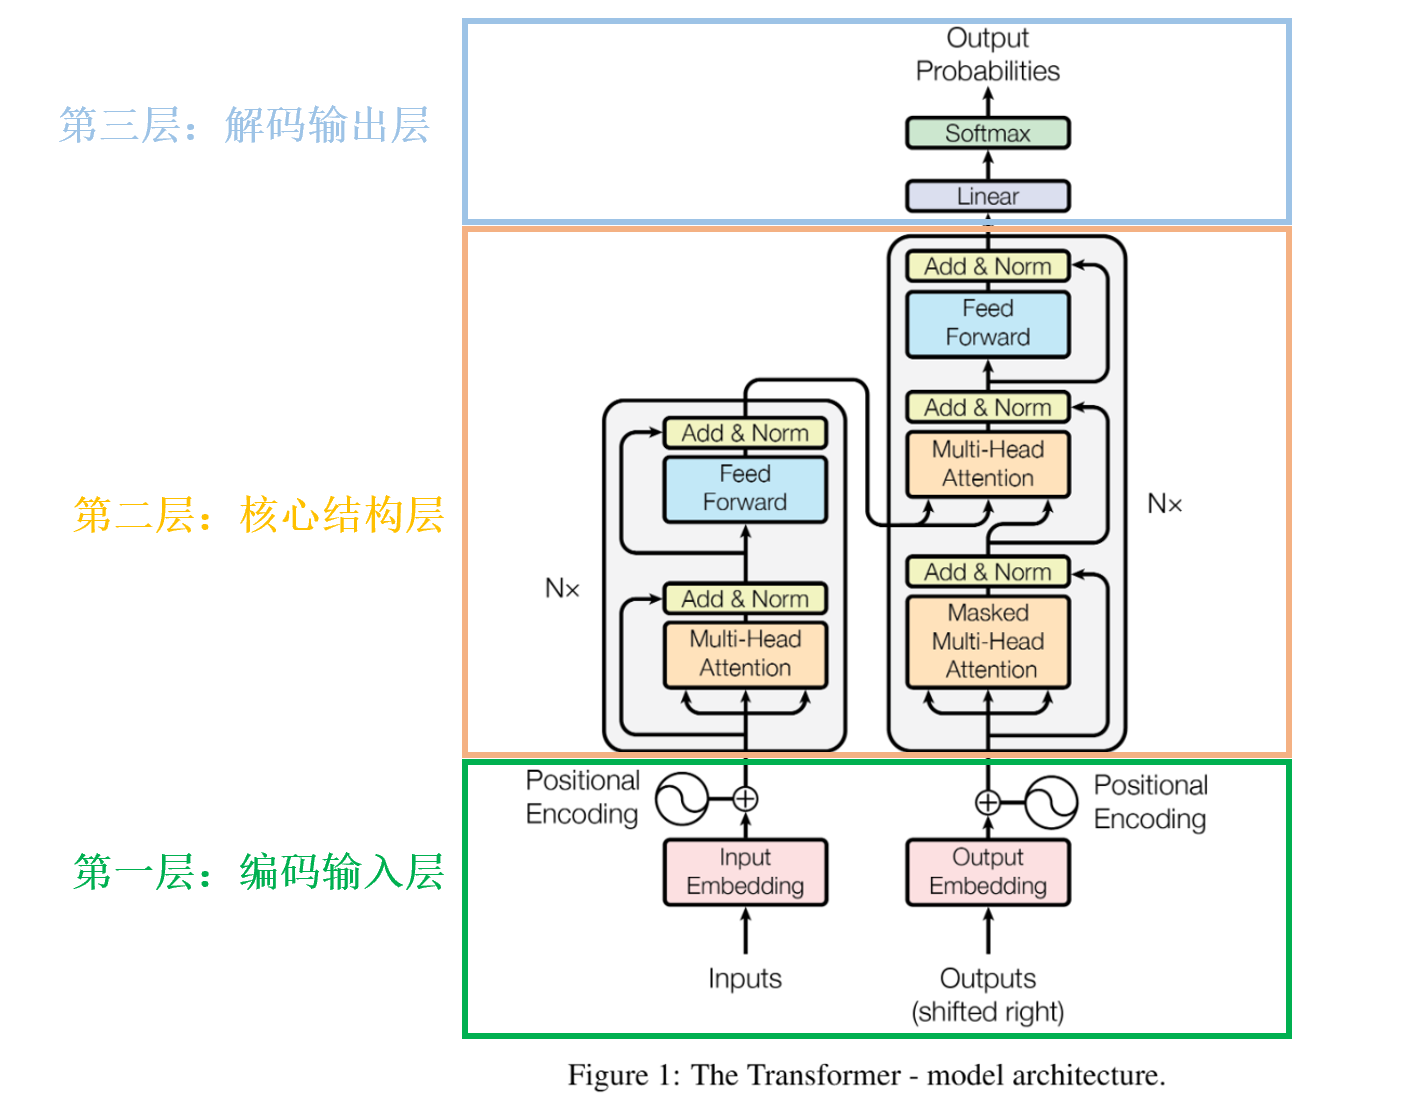

该结构图来自论文Attention is all you need，是最经典的Transformer架构图

实现Transformer主要分为两个部分：左边部分的Encoder和右边部分的Decoder，从结构上来看可分为输入层、核心结构层、输出层

| 结构 | 组件 | 输入 | 输出 | 作用 |
| --- | --- | --- | --- | --- |
| 输入层| 分词`tokenizer`，向量编码`embedding`、位置编码`positional encoding` | 原始的自然语言text,`shape = [batch, seq_len]` | 经向量编码和位置编码后编码好的向量，`shape = [batch, seq_len, d_model]` | 对原始自然语言文本进行编码处理，方便后续计算 |
| 核心结构层 | attention机制、FFN前馈神经网络、Add&Norm残差连接与层归一化 | 编码向量，`shape = [batch, seq_len, d_model]` | 计算后的向量，`shape = [batch, seq_len, d_model]` | 可以将Encoder和Decoder分开，组合起来是完整的Transformer架构，适用于不同的模型和任务 |
| 输出层 | 线性层映射与softmax | 经核心结构层计算后的向量 | 下一个位置的输出token的预测，`shape = [batch, vocab_size]`，从中按照一定的解码策略选择输出的预测token | 最终得到输出，对于输出策略一般采用贪心策略 |

实现思路：根据顺序从输入层->核心结构层（分为Encoder和Decoder）->输出层

In [58]:
from torch import nn
import torch

## 第一部分：基本组件

这一部分实现Transformer的输入层和核心结构层的四大基本组件

### 输入层：分词->向量编码+位置编码

分词由tokenizer完成，一般调用现有的tokenizer（在完整的训练过程中调用）

向量编码由前置的embedding层完成，调用官方的`nn.Embedding`层（见后）

以下是位置编码的实现

In [59]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len = 512):
        super().__init__()
        position = torch.arange(0, max_seq_len).unsqueeze(1)
        item = 1 / 10000**(torch.arange(0, d_model, 2) / d_model)
        tmp_pos = position * item

        pe = torch.zeros(max_seq_len, d_model)
        pe[:, 0::2] = torch.sin(tmp_pos)
        pe[:, 1::2] = torch.cos(tmp_pos)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe, False)

    def forward(self, x):
        batch, seq_len, d_model = x.shape
        pe = self.pe
        return x + pe[:, :seq_len, :]

positional encoding的计算公式：

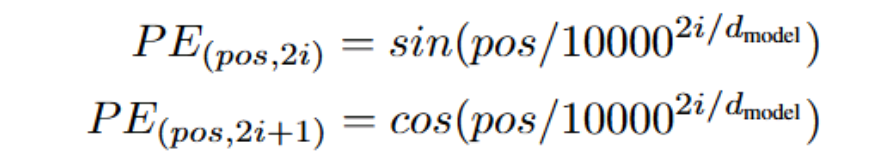

思路：创建pos和item，创建位置编码矩阵pe，每一行对应一个 token 的位置 pos，每两列是一组相同频率的 sin 和 cos

pe矩阵的每一行代表该序列中的一个token的位置向量：


$$ {\bf{P}}{{\bf{E}}_{pos,:}} = \left[ {\sin \left( {\frac{{pos}}{{{{10000}^{0/{d_{{\rm{model}}}}}}}}} \right),\cos \left( {\frac{{pos}}{{{{10000}^{0/{d_{{\rm{model}}}}}}}}} \right),\sin \left( {\frac{{pos}}{{{{10000}^{2/{d_{{\rm{model}}}}}}}}} \right),\cos \left( {\frac{{pos}}{{{{10000}^{2/{d_{{\rm{model}}}}}}}}} \right), \ldots ,\sin \left( {\frac{{pos}}{{{{10000}^{({d_{{\rm{model}}}} - 2)/{d_{{\rm{model}}}}}}}}} \right),\cos \left( {\frac{{pos}}{{{{10000}^{({d_{{\rm{model}}}} - 2)/{d_{{\rm{model}}}}}}}}} \right)} \right]. $$

靠前的列（低维）变化快，靠后的列（高维）变化慢，因此模型能借此区分绝对位置和相对距离

最终将input embedding 和 positional embedding 相加作为输入，给核心层进行计算

输入的数据shape: `[batch, seq_len, d_model]`

### 核心结构层前置：Attention计算公式

In [61]:
def attention(query, key, value, mask = None):
    d_model = key.shape[-1]
    att_ = torch.matmul(query, key.transpose(-2, -1))/(d_model**0.5)

    if mask is not None:
        att_ = att_.masked_fill(mask, -1e9)

    att_score = torch.softmax(att_, -1)
    return torch.matmul(att_score, value)

核心公式：

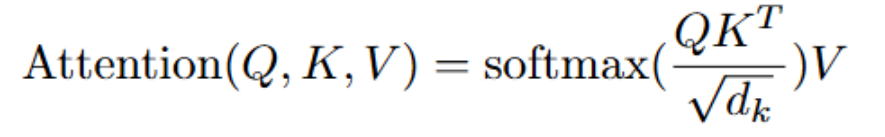

通用的Attention计算函数，mask为可选择的是否要传入的参数

mask的作用：
在Transformer架构的各个attention中用到的mask，最终都会进入`attention()`函数，用来控制控制各个位置的attention能看哪些位置，不能看哪些位置

`mask=True`表示这个位置要被遮住，不能关注，`mask=False`表示这个位置可以正常关注

被 mask 的位置会被替换成一个极小值 `-1e9`。经过 softmax 后，这些位置的注意力权重会接近 0，从而实现掩码

接下来详细了解掩码。Transformer里一共有三种mask：

| mask 名称 | 使用位置 | 生成方式 | 遮住什么 | 作用 |
| --- | --- | --- | --- | --- |
| `src_mask` | Encoder self-attention | `generate_mask(src, src)` | `src` 里的 `<pad>` | Encoder 不关注源句子的 padding |
| `dst_mask` | Decoder masked self-attention | `generate_mask(dst, dst, True)` | `dst` 里的 `<pad>` 和未来 token | Decoder 不关注 padding，也不能偷看未来 |
| `src_dst_mask` | Decoder cross-attention | `generate_mask(dst, src)` | `src` 里的 `<pad>` | Decoder 看 Encoder 时跳过源句子的 padding |

在Transformer中的具体位置：
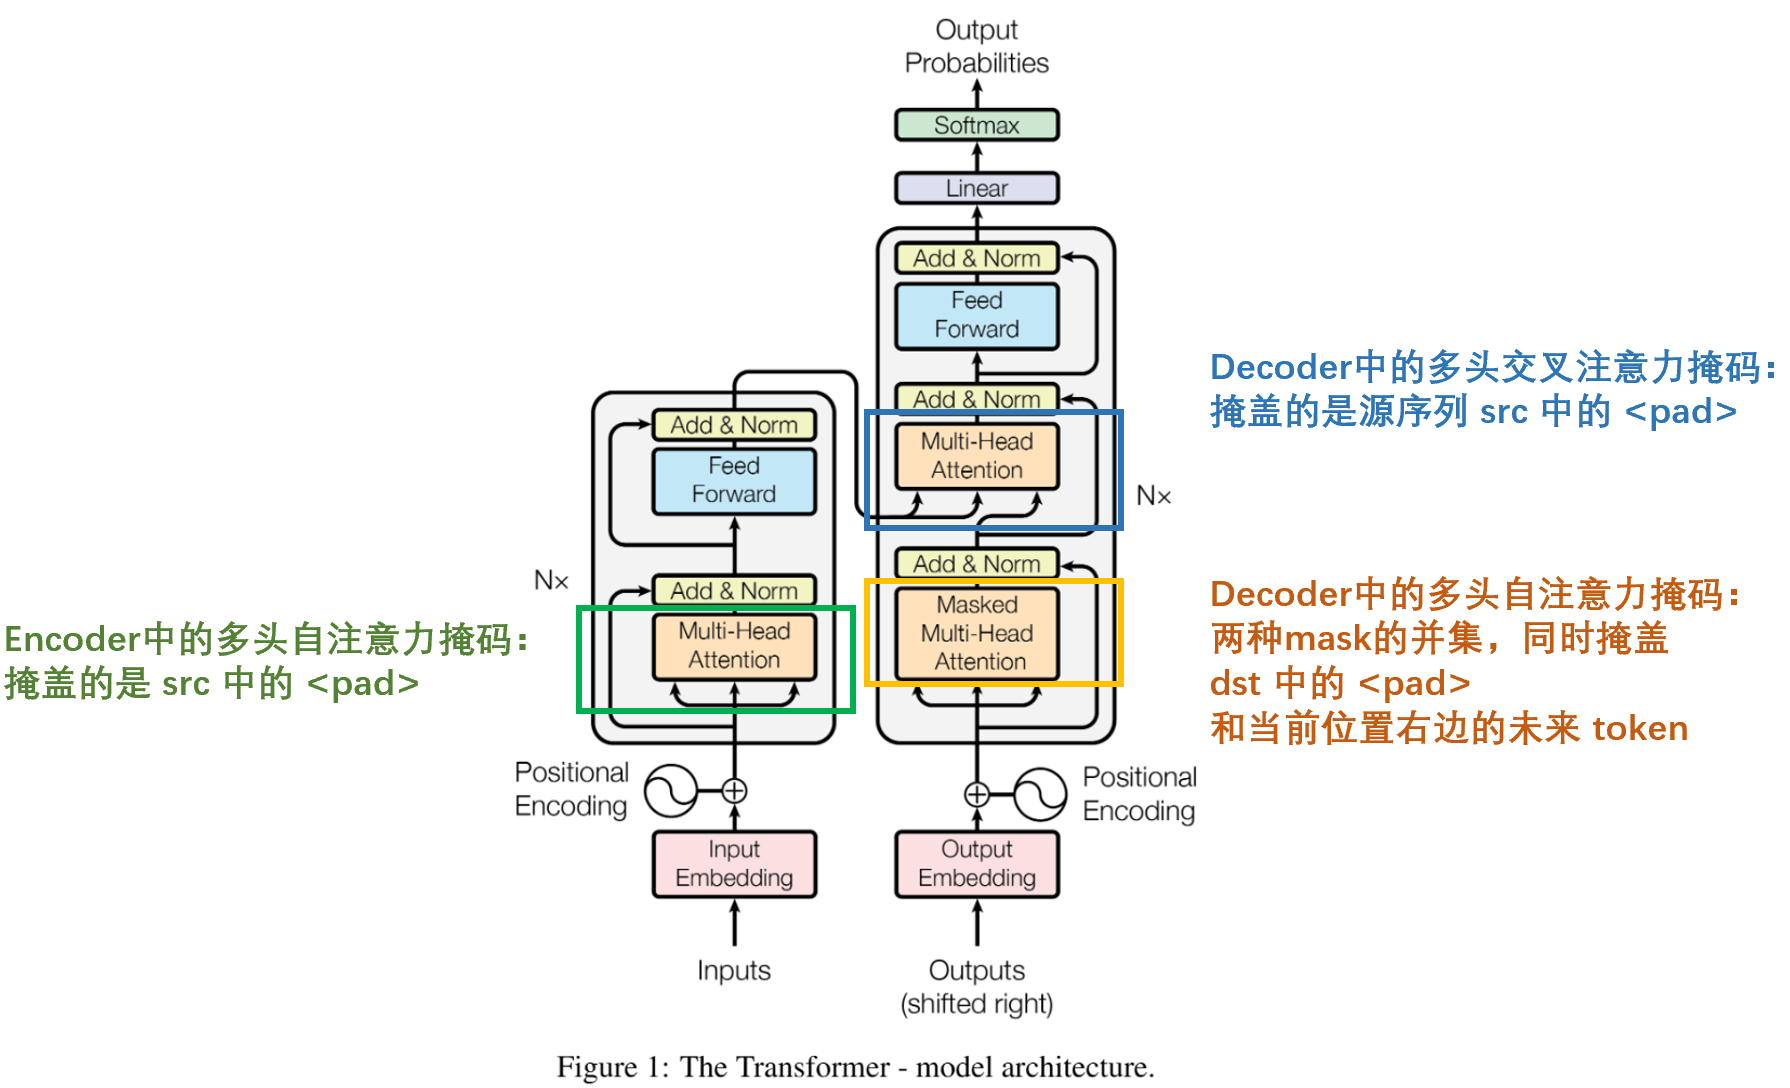

Encoder 忽略源句子的补齐；Decoder 自注意力既忽略补齐又不能偷看未来；交叉注意力在读取 Encoder 时忽略源句子的补齐

三种 mask 都统一由 `generate_mask()` 生成，最后都在 `attention()` 里的 `masked_fill_(mask, -1e9)` 生效

 `generate_mask()`在后续实现

### 核心结构层之一：多头注意力机制

多头注意力机制实际上就是用了多个K、Q、V矩阵，最后拼接到一起

一共heads个头，每个头的维度为d_k，拼在一起一共d_model维

In [51]:
class MultiHeadAttention(nn.Module):
    def __init__(self, heads, d_model, dropout):
        super().__init__()
        assert d_model % heads == 0
        self.q_linear = nn.Linear(d_model, d_model, bias = False)
        self.k_linear = nn.Linear(d_model, d_model, bias = False)
        self.v_linear = nn.Linear(d_model, d_model, bias = False)
        self.linear = nn.Linear(d_model, d_model, bias = False)
        self.dropout = nn.Dropout(dropout)
        self.heads = heads
        self.d_k = d_model // heads
        self.d_model = d_model

    def forward(self, x_q, x_k, x_v, mask = None):
        q = self.q_linear(x_q).reshape(x_q.shape[0], -1, self.heads, self.d_k).transpose(1, 2)
        k = self.k_linear(x_k).reshape(x_k.shape[0], -1, self.heads, self.d_k).transpose(1, 2)
        v = self.v_linear(x_v).reshape(x_v.shape[0], -1, self.heads, self.d_k).transpose(1, 2)
        out = attention(q, k, v, mask)
        out = out.transpose(1, 2).reshape(out.shape[0], -1, self.d_model)
        out = self.linear(out)
        out = self.dropout(out)
        return out


思路：实现一个多头注意力机制需要计算attention，再经过Linear和Dropout这两个经典操作后输出

多头拼接过程：
1. 传入的x的shape：[batch, seq_len, d_model]

2. 将其拆开为[batch, seq_len, heads, d_k]，为了方便计算attention，将其transpose为[batch, heads, seq_len, d_k]

3. 进行attention计算后，维度为[batch, heads, seq_len, seq_len]，为了方便拼接，将其transpose为[batch, seq_len, heads, seq_len]

4. 再把多个头的attention结果拼接起来，得到[batch, seq_len, d_model]



### 核心结构层之二：前馈神经网络

前馈神经网络FeedForward Network（FNN）也是深度学习神经网络中的经典结构，在Transformer中主要起一个再度映射的作用

将维度从d_model映射到较高维度，再映射回d_model

网络结构：

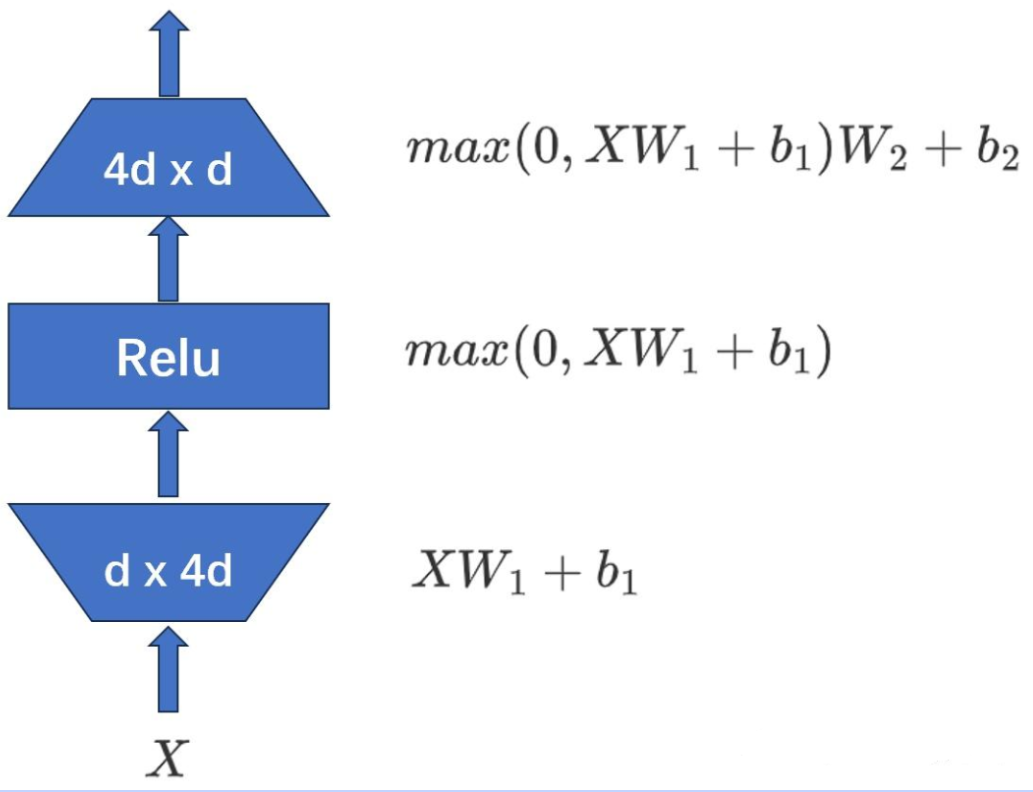

采用ReLU激活函数，当下在FFN层的主流激活函数也有SwiGLU

In [52]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff, bias = False),
            nn.ReLU(),
            nn.Linear(d_ff, d_model, bias = False),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.ffn(x)

### 核心结构层之三：残差连接与归一化

残差连接Add：不损失原始值的梯度向下传递，防止梯度爆炸

层归一化Norm：深度学习中常用的归一化方法包括：批归一化、层归一化、组归一化。Transformer采用的是层归一化，即对单个样本内部的特征维度做归一化，能够保持数据分布稳定性

直接在网络结构里实现

## 第二部分：block组合

这一部分将第一部分的基本组件组合起来，形成Encoder和Decoder Layer，通过多个Layer的重叠，实现Encoder和Decoder

### 1. 组装一个Encoder Layer

把MultiHeadAttention+FFN+Add&Norm组合起来，形成一个Encoder Block

In [53]:
class EncoderLayer(nn.Module):
    def __init__(self, heads, d_model, d_ff, dropout = 0.1):
        super().__init__()
        self.self_multihead_att = MultiHeadAttention(heads, d_model, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for i in range(2)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask = None):
        multihead_att_out = self.self_multihead_att(x, x, x, mask)
        multihead_att_out = self.norms[0](x + multihead_att_out)
        ffn_out = self.ffn(multihead_att_out)
        ffn_out = self.norms[1](multihead_att_out + ffn_out)
        out = self.dropout(ffn_out)
        return out

### 2. 组装一个Encoder

把多个Encoder Block组装起来，加上向量编码和位置编码，形成一个完整的Encoder模块

In [54]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, pad_idx, d_model, num_layers, heads, d_ff, dropout, max_seq_len = 512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, pad_idx)
        self.position_encode = PositionalEncoding(d_model, max_seq_len)
        self.encoder_layers = nn.ModuleList([EncoderLayer(heads, d_model, d_ff, dropout) for i in range(num_layers)])
    
    def forward(self, x, src_mask):
        embed_x = self.embedding(x) * (self.embedding.embedding_dim ** 0.5)
        pos_encode_x = self.position_encode(embed_x)
        for layer in self.encoder_layers:
            pos_encode_x = layer(pos_encode_x, src_mask)
        return pos_encode_x

这里用到了nn.Embedding层，注意官方对nn.Embedding的解释：
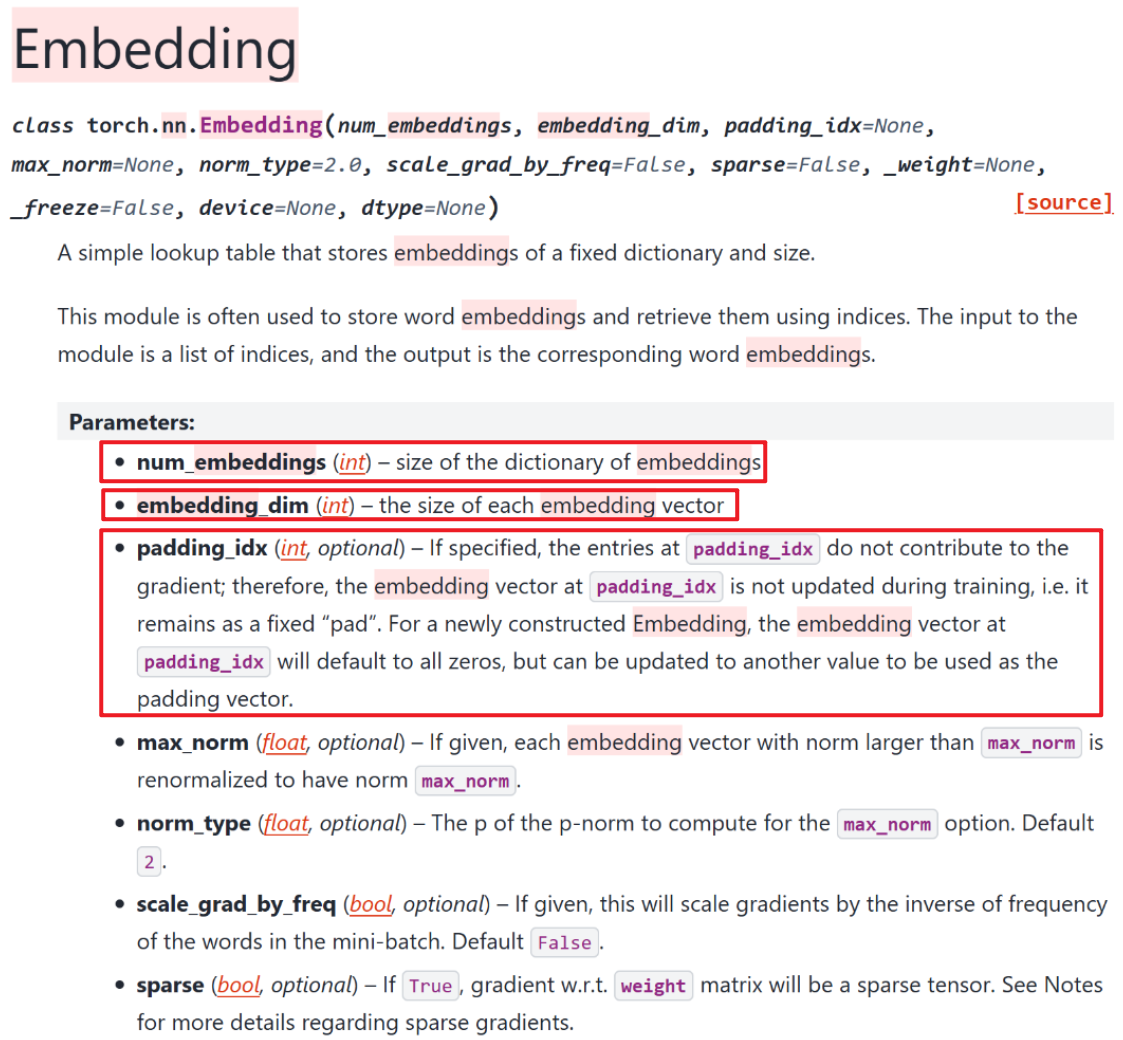

这里出现了三个参数：`vocab_size`, `d_model`, `pad_idx`，是embedding需要具备的要素，分别代表：
- 词表大小
- embedding维度
- 不需要计算梯度、不参与训练的标识符


### 3. 组装一个Decoder Layer

Decoder Layer的结构和Encoder Layer的结构基本类似，区别在于加入不能看见未来预测未知的Decoder自注意力掩码和交叉注意力

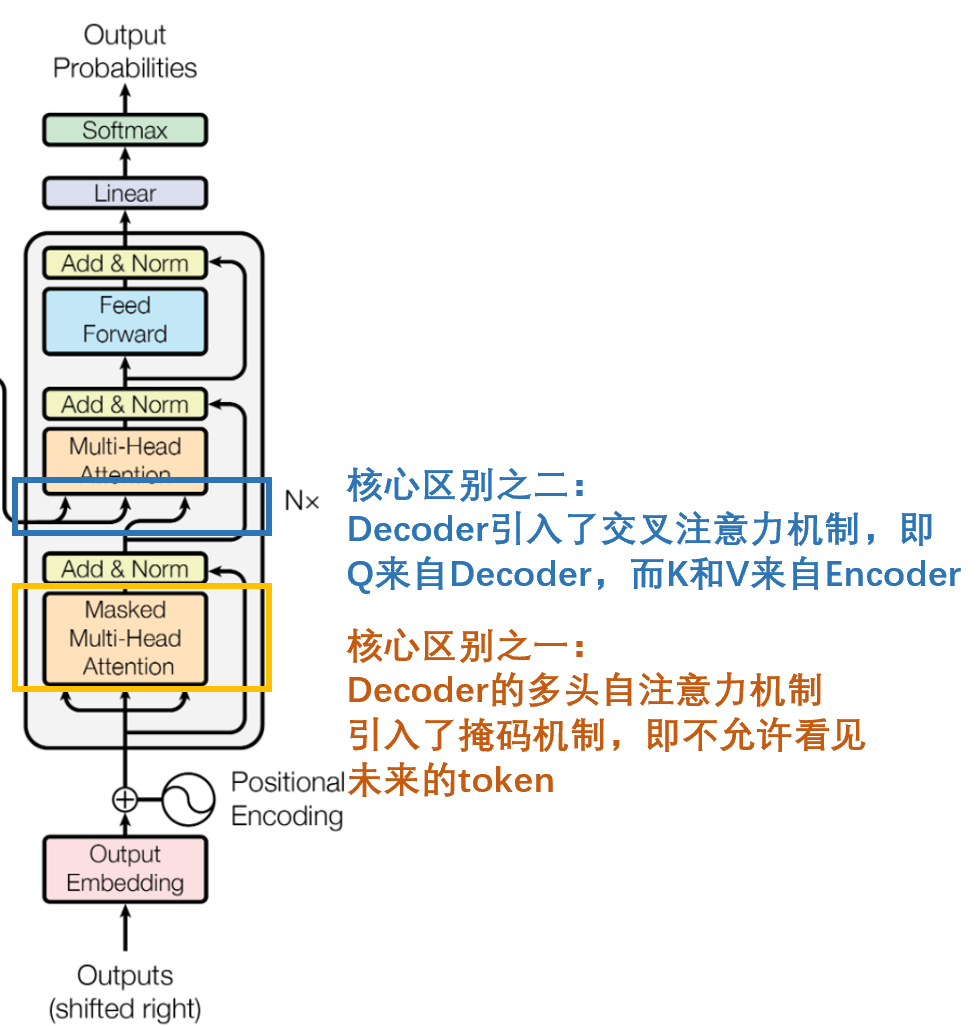

In [55]:
class DecoderLayer(nn.Module):
    def __init__(self, heads, d_model, d_ff, dropout):
        super().__init__()
        self.masked_att = MultiHeadAttention(heads, d_model, dropout)
        self.att = MultiHeadAttention(heads, d_model, dropout)
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for i in range(3)])
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encode_kv, dst_mask, src_dst_mask):
        mask_att_out = self.masked_att(x, x, x, dst_mask)
        mask_att_out = self.norms[0](x + mask_att_out)
        att_out = self.att(mask_att_out, encode_kv, encode_kv, src_dst_mask)
        att_out = self.norms[1](mask_att_out + att_out)
        ffn_out = self.ffn(att_out)
        ffn_out = self.norms[2](att_out + ffn_out)
        out = self.dropout(ffn_out)
        return out

### 4. 组装一个Decoder

把多个Decoder Block组装起来，加上向量编码和位置编码，形成一个完整的Decoder模块

In [56]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, pad_idx, d_model, num_layers, heads, d_ff, dropout, max_seq_len = 512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, pad_idx)
        self.position_encode = PositionalEncoding(d_model, max_seq_len)
        self.decoder_layers = nn.ModuleList([DecoderLayer(heads, d_model, d_ff, dropout) for i in range(num_layers)])

    def forward(self, x, encoder_kv, dst_mask = None, src_dst_mask = None):
        embed_x = self.embedding(x) * (self.embedding.embedding_dim ** 0.5)
        pos_encode_x = self.position_encode(embed_x)
        for layer in self.decoder_layers:
            pos_encode_x = layer(pos_encode_x, encoder_kv, dst_mask, src_dst_mask)
        return pos_encode_x


## 第三部分：组装成完整的Transformer架构

接下来将以上的Encoder和Decoder组装起来，加入输出层的组件，如线性层、输出层，以及掩码生成函数，实现一个完整的Transformer架构

In [57]:
class Transformer(nn.Module):
    def __init__(self,enc_vocab_size, dec_vocab_size, pad_idx, d_model, num_layers, heads, d_ff, dropout, max_seq_len):
        super().__init__()
        self.encoder = Encoder(enc_vocab_size, pad_idx, d_model, num_layers, heads, d_ff, dropout, max_seq_len)
        self.decoder = Decoder(dec_vocab_size, pad_idx, d_model, num_layers, heads, d_ff, dropout, max_seq_len)
        self.linear = nn.Linear(d_model, dec_vocab_size)
        self.pad_idx = pad_idx

    def generate_mask(self, query, key, is_triu_mask = False):
        device = query.device
        batch, seq_q = query.shape
        _, seq_k = key.shape
        mask = (key == self.pad_idx).unsqueeze(1).unsqueeze(2)
        mask = mask.expand(batch, 1, seq_q, seq_k).to(device)

        if is_triu_mask:
            dst_triu_mask = torch.triu(torch.ones(seq_q, seq_k, dtype = torch.bool), diagonal = 1)
            dst_triu_mask = dst_triu_mask.unsqueeze(0).unsqueeze(1).expand(batch, 1, seq_q, seq_k).to(device)
            return mask | dst_triu_mask
        return mask
        
    def forward(self, src, dst):
        src_mask = self.generate_mask(src, src)
        encoder_out = self.encoder(src, src_mask)
        dst_mask = self.generate_mask(dst, dst, True)
        src_dst_mask = self.generate_mask(dst, src)
        decoder_out = self.decoder(dst, encoder_out, dst_mask, src_dst_mask)
        out = self.linear(decoder_out)
        return out

理解这一段中的mask的维度怎么写的：

1. mask 

多头注意力中的分数计算为：`scores = Q @ K.transpose(-2, -1)`，所以维度为`[batch, heads, seq_q, seq_k]`，因此mask被处理为`[batch, 1, seq_q, seq_k]`，`1`表示同一个mask供所有注意力头广播使用

进行`key == self.pad_idx`得到维度为`[batch, seq_k]`

再经过unsqueeze，变为`[batch, 1, 1, seq_k]`，分别对应`[batch, head, query位置, key位置]`，然后将其expand为`[batch, 1, seq_q, seq_k]`，和`[batch, heads, seq_q, seq_k]`计算时会自动广播

2. is_triu_mask

生成主对角线和下方为 `False`，主对角线上方为 `True` 的矩阵，这样每个 token 可以看到自己和过去，但不能看到未来，维度依然为`[batch, 1, seq_q, seq_k]`，最后取并集


思路：到最后forward函数里只需要传递序列和需要的mask，调用mask生成函数和encoder与decoder即可